In [68]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

In [69]:
df = pd.read_csv('S06-hw-dataset-02.csv')

In [70]:
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

In [72]:
df.describe()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


In [73]:
print(df['target'].value_counts(normalize=True))

target
0    0.737389
1    0.262611
Name: proportion, dtype: float64


In [74]:
df.isna().sum()

id         0
f01        0
f02        0
f03        0
f04        0
f05        0
f06        0
f07        0
f08        0
f09        0
f10        0
f11        0
f12        0
f13        0
f14        0
f15        0
f16        0
f17        0
f18        0
f19        0
f20        0
f21        0
f22        0
f23        0
f24        0
f25        0
f26        0
f27        0
f28        0
f29        0
f30        0
f31        0
f32        0
f33        0
f34        0
f35        0
x_int_1    0
x_int_2    0
target     0
dtype: int64

Рассмотрен второй датасет, который содержит 37 численных признаков и 18000 объектов. В нем отсутствуют пропуски, баланс классов завален в сторону класса "0", в отношении 74:26.

In [75]:
df = df.drop(columns=['id'])

In [76]:
X = df.drop(columns=['target'])
y = df['target']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Фиксорованный seed важен для воспроизводимости результатов, а стратификация необходима для одинакового распределения классов в train и test, таком же как и в полном датасете. 

In [78]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

acc_dummy = accuracy_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_proba_dummy)


In [79]:
search_summaries = {}
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0]
}

lr_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="roc_auc",     
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

best_model_lr = lr_search.best_estimator_
best_param_lr = lr_search.best_params_

y_pred_lr = best_model_lr.predict(X_test)
y_proba_lr = best_model_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

search_summaries['logistic_regression'] = {
    'best_params': lr_search.best_params_,
    'best_cv_score': lr_search.best_score_
}


Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [80]:
dec_tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    "max_depth": [2, 4, 8, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

dt_search = GridSearchCV(
    dec_tree,
    param_grid,
    cv=5,
    scoring="roc_auc",     
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train, y_train)

best_model_dt = dt_search.best_estimator_
best_param_dt = dt_search.best_params_

y_pred_dt = best_model_dt.predict(X_test)
y_proba_dt = best_model_dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

search_summaries['decision_tree'] = {
    'best_params': dt_search.best_params_,
    'best_cv_score': dt_search.best_score_
}


Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [81]:
forest = RandomForestClassifier(random_state=42)
param_grid = {
    "max_depth": [2, 4, 8, 10]
}

forest_search = GridSearchCV(
    forest,
    param_grid,
    cv=5,
    scoring="roc_auc",     
    n_jobs=-1,
    verbose=1
)

forest_search.fit(X_train, y_train)

best_model_forest = forest_search.best_estimator_
best_param_forest = forest_search.best_params_

y_pred_forest = best_model_forest.predict(X_test)
y_proba_forest = best_model_forest.predict_proba(X_test)[:, 1]

acc_forest = accuracy_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest)
auc_forest = roc_auc_score(y_test, y_proba_forest)

search_summaries['random_forest'] = {
    'best_params': forest_search.best_params_,
    'best_cv_score': forest_search.best_score_
}

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [82]:
ada_boost = AdaBoostClassifier()
param_grid = {
    "n_estimators": [5, 10, 25, 50]
}

boost_search = GridSearchCV(
    forest,
    param_grid,
    cv=5,
    scoring="roc_auc",     
    n_jobs=-1,
    verbose=1
)

boost_search.fit(X_train, y_train)

best_model_boost = boost_search.best_estimator_
best_param_boost = boost_search.best_params_

y_pred_boost = best_model_boost.predict(X_test)
y_proba_boost = best_model_boost.predict_proba(X_test)[:, 1]

acc_boost = accuracy_score(y_test, y_pred_boost)
f1_boost = f1_score(y_test, y_pred_boost)
auc_boost = roc_auc_score(y_test, y_proba_boost)

search_summaries['ada_boost'] = {
    'best_params': boost_search.best_params_,
    'best_cv_score': boost_search.best_score_
}

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [83]:
metrics_test = pd.DataFrame({
    "Model": ["Dummy (most_frequent)", "Log_regression", "Decision_tree", "Random_forest", "AdaBoost"],
    "Accuracy": [acc_dummy, acc_lr, acc_dt, acc_forest, acc_boost],
    "f1-score": [f1_dummy, f1_lr, f1_dt, f1_forest, f1_boost],
    "ROC-AUC": [auc_dummy, auc_lr, auc_dt, auc_forest, auc_boost]
})
results.round(4)

,Model,Accuracy,f1-score,ROC-AUC
0,Dummy (most_frequent),0.7375,0.0000,0.5000
1,Log_regression,0.8119,0.5607,0.7977
2,Decision_tree,0.8383,0.6576,0.8371
3,Random_forest,0.8656,0.6803,0.9152
4,AdaBoost,0.8839,0.7391,0.9237


Среди всех использованных моделей с их лучшими параметрами по всем метрикам показывает лучший результат AdaBoostClassifier.

In [84]:
# Выбор лучшей модели
best_idx = metrics_test['ROC-AUC'].idxmax()
best_model = metrics_test.loc[best_idx, 'Model']
best_auc = metrics_test.loc[best_idx, 'ROC-AUC']
best_f1 = metrics_test.loc[best_idx, 'f1-score']
best_acc = metrics_test.loc[best_idx, 'Accuracy']

In [87]:
import joblib
import json
from pathlib import Path

def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

metrics_path = Path("artifacts/metrics_test.json")
search_path = Path("artifacts/search_summaries.json")


metrics_test.to_csv(metrics_path, index=False)
save_json(search_summaries, search_path)

model_path = "artifacts/best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model": best_model,
    "test_acc": best_acc,
    "test_f1": best_f1,
    "test_roc_auc": best_auc,
    "best_param": boost_search.best_params_}

save_json(meta, Path("artifacts/best_model_meta.json"))


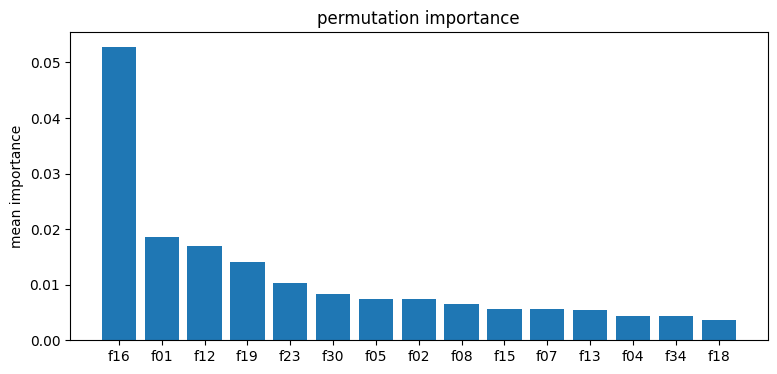

In [98]:
feature_names = list(X.keys())

result_imp = permutation_importance(
    best_model_boost,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy"
)

imp = result_imp.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(range(len(idx)), [feature_names[i] for i in idx])
plt.ylabel('mean importance')
plt.title('permutation importance')
plt.savefig("artifacts/figures/importance.png")
plt.show()

Признак 16 влияет на результат сильнее всего.

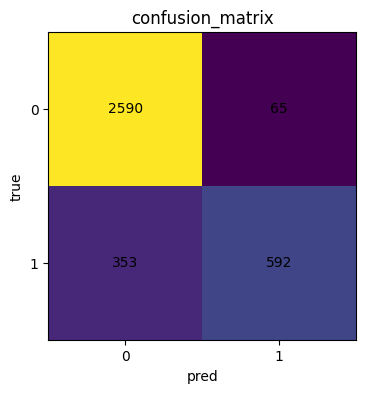

In [94]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('confusion_matrix')
plt.xlabel("pred")
plt.ylabel("true")
plt.xticks([0, 1])
plt.yticks([0, 1])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.savefig("artifacts/figures/confusion.png")
plt.show()

